# Course Project - Bankruptcy trends in Finland by industry and Euribor
Author: Leander Byggmästar

## Introduction

This project analyzes bankruptcy proceedings initiated in Finland from 2003 onwards. The goal of the project is to study how bankruptcies have developed over time and between industries.

The project also combines the bankruptcy data with 12-month Euribor data from the ECB Data Portal to investigate whether changes in interest rates are associated with changes in bankruptcy proceedings.

**Research question:**
How have bankruptcy proceedings in Finland developed by industry, and is there an association between bankruptcies and the 12-month Euribor rate?

## How to use this notebook

1. Run the notebook in the right order, from top to bottom
2. The notebook collects bankruptcy data from Statistics Finland's PxWeb API and Euribor data from ECB Data Portal API
3. The raw datasets are saved in the `data` folder as CSV files
4. If the APIs are unavailable, the saved CSV files can be loaded by uncommenting the backup loading cell
5. The notebook cleans the data, creates yearly summary tables and visualizes the results
6. The results are exported to the folder `results`

## Data Pipeline

![Data pipeline](images/data_pipeline.png)

## 1. Data extraction

#### 1.1 Statistics Finland API

In [1]:
import pandas as pd
import requests
from pyjstat import pyjstat
import os

query = {
  "query": [
    {
      "code": "Toimiala_luok",
      "selection": {
        "filter": "item",
        "values": [
          "A",
          "B-E",
          "F",
          "G",
          "H",
          "I",
          "J-U",
          "X"
        ]
      }
    },
    {
      "code": "Tiedot",
      "selection": {
        "filter": "item",
        "values": [
          "kylkm"
        ]
      }
    }
  ],
  "response": {
    "format": "json-stat2"
  }
}

response = requests.post("https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin/kony/statfin_kony_pxt_13fe.px", json=query)

print(f"Status code: {response.status_code}")
response.raise_for_status()

data = response.json()
results = pyjstat.from_json_stat(data)
df = pd.DataFrame(results[0])

# Saves the raw data
os.makedirs("data", exist_ok=True)
df.to_csv("data/raw_data_bankruptcy.csv", index=False)

Status code: 200


#### 1.2 ECB Open Data

In [2]:
url = "https://data-api.ecb.europa.eu/service/data/FM/M.U2.EUR.RT.MM.EURIBOR1YD_.HSTA"

params_ecb = {
    "startPeriod": "2003-01",
    "format": "csvdata"
}

response_ecb = requests.get(url, params=params_ecb)

print(f"Status code: {response_ecb.status_code}")
response_ecb.raise_for_status()

# Save raw data as csv to the folder data
os.makedirs("data", exist_ok=True)
with open("data/raw_data_euribor.csv", "w", encoding="UTF-8") as f:
    f.write(response_ecb.text)

df_euribor = pd.read_csv("data/raw_data_euribor.csv")

Status code: 200


#### 1.3 Load data if API is unavailable

In [ ]:
# # Load the saved data if the API is unavailable

# df = pd.read_csv("data/raw_data_bankruptcy.csv")
# df_euribor = pd.read_csv("data/raw_data_euribor.csv")

#### 1.4 Data exploration

In [4]:
print(f"Shape: {df.shape}")
display(df.head())
df.info()
df.describe()

Shape: (2232, 4)


,Month,Industries_luok,Information,value
0,2003M01,"Agriculture, forestry and fishing","Bankruptcies instigated, number of enterprises",6
1,2003M01,"Manufacturing, mining and energy and water supply","Bankruptcies instigated, number of enterprises",33
2,2003M01,Construction,"Bankruptcies instigated, number of enterprises",28
3,2003M01,Trade,"Bankruptcies instigated, number of enterprises",32
4,2003M01,Transport and storage,"Bankruptcies instigated, number of enterprises",17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2232 entries, 0 to 2231
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Month            2232 non-null   object
 1   Industries_luok  2232 non-null   object
 2   Information      2232 non-null   object
 3   value            2232 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 69.9+ KB


,value
count,2232.000000
mean,28.789875
std,23.393985
min,0.000000
25%,10.000000
50%,23.000000
75%,43.000000
max,152.000000


In [5]:
df_euribor = df_euribor[["TIME_PERIOD", "OBS_VALUE"]]

print(f"Shape: {df_euribor.shape}")
display(df_euribor.head())
df_euribor.info()
df_euribor.describe()

Shape: (280, 2)


,TIME_PERIOD,OBS_VALUE
0,2003-01,2.704546
1,2003-02,2.503550
2,2003-03,2.411191
3,2003-04,2.446950
4,2003-05,2.252095


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TIME_PERIOD  280 non-null    object 
 1   OBS_VALUE    280 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.5+ KB


,OBS_VALUE
count,280.000000
mean,1.577662
std,1.608241
min,-0.504700
25%,-0.016443
50%,1.458213
75%,2.461100
max,5.393217


## 2. Cleaning and transformation

In [6]:
## Bankruptcy dataset

# Adds year column
df = pd.DataFrame(results[0])
df["year"] = df["Month"].str[:4].astype(int)

# Removes year if data for the entire year is not available
unique_months = df.pivot_table(index=["Month", "year"], values="value").reset_index()
month_count = unique_months.pivot_table(index="year", values="Month", aggfunc="count").reset_index()
complete_years = list(month_count[month_count.Month == 12]["year"])

df = df[df["year"].isin(complete_years)]

# Gets the first and last year of the data
year_start = df["year"].loc[df["year"].idxmin()]
year_end = df["year"].loc[df["year"].idxmax()]

# Sum of bankruptcies by year
df_by_year = df.pivot_table(index=["year"],
                            values="value",  
                            aggfunc="sum").reset_index()

print("Sum of bankruptcies by year")
display(df_by_year.head(3))

# Sum of bankruptcies grouped by industry
df_by_industry = df.pivot_table(index=["year", "Industries_luok"],
                            values="value",  
                            aggfunc="sum").reset_index()

print("Sum of bankruptcies grouped by industry")
display(df_by_industry.head(3))

# Total bankruptcies per industry
df_industry_total = df_by_industry.pivot_table(index="Industries_luok",
                            values="value",  
                            aggfunc="sum").reset_index()

print("Total bankruptcies per industry")
display(df_industry_total.head(3))

Sum of bankruptcies by year


,year,value
0,2003,2769
1,2004,2428
2,2005,2278


Sum of bankruptcies grouped by industry


,year,Industries_luok,value
0,2003,"Agriculture, forestry and fishing",52
1,2003,Construction,473
2,2003,Hotels and restaurants,183


Total bankruptcies per industry


,Industries_luok,value
0,"Agriculture, forestry and fishing",1477
1,Construction,13745
2,Hotels and restaurants,5264


In [7]:
## Euribor dataset

df_euribor = pd.read_csv("data/raw_data_euribor.csv")[["TIME_PERIOD", "OBS_VALUE"]]

# Adds year column
df_euribor["year"] = df_euribor["TIME_PERIOD"].str[:4].astype(int)

# Removes data from years outside of the bankruptcy data
df_euribor = df_euribor[df_euribor["year"].isin(complete_years)]

df_euribor_by_year = df_euribor.pivot_table(index="year",
                                            values="OBS_VALUE",
                                            aggfunc="mean").reset_index()

df_euribor_by_year = df_euribor_by_year.rename(columns={
    "OBS_VALUE": "value"
})

df_euribor_by_year.head(3)

,year,value
0,2003,2.336494
1,2004,2.273701
2,2005,2.334136


In [8]:
## Combining datasets and calculating percentage change

# Calculates the change of bankruptcies and the percentage change
df_by_year["yearly_change"] = df_by_year["value"].diff()
df_by_year["percentage_change"] = df_by_year["value"].pct_change() * 100

# Calculates the change in Euribor
df_euribor_by_year["percentage_change"] = df_euribor_by_year["value"].diff()

# Merges the tables including percentage change
df_combined = df_by_year[["year", "value", "percentage_change"]].merge(right=df_euribor_by_year[["year", "value", "percentage_change"]], how="inner", on="year", suffixes=("_bankruptcy", "_euribor")).dropna()

df_long = df_combined.melt(
    id_vars="year",
    value_vars=["percentage_change_bankruptcy", "percentage_change_euribor"],
    var_name="Series",
    value_name="percentage_change"
)

df_long["Series"] = df_long["Series"].replace({
    "percentage_change_bankruptcy": "Bankruptcy",
    "percentage_change_euribor": "Euribor"
})

print("df in long format")
display(df_long.head(3))
print("Bankruptcy combined with Euribor")
display(df_combined.head(3))

df in long format


,year,Series,percentage_change
0,2004,Bankruptcy,-12.314915
1,2005,Bankruptcy,-6.177924
2,2006,Bankruptcy,0.307287


Bankruptcy combined with Euribor


,year,value_bankruptcy,percentage_change_bankruptcy,value_euribor,percentage_change_euribor
1,2004,2428,-12.314915,2.273701,-0.062793
2,2005,2278,-6.177924,2.334136,0.060435
3,2006,2285,0.307287,3.436300,1.102164


## 3. Analysis and visualization

#### 3.1 Visualization

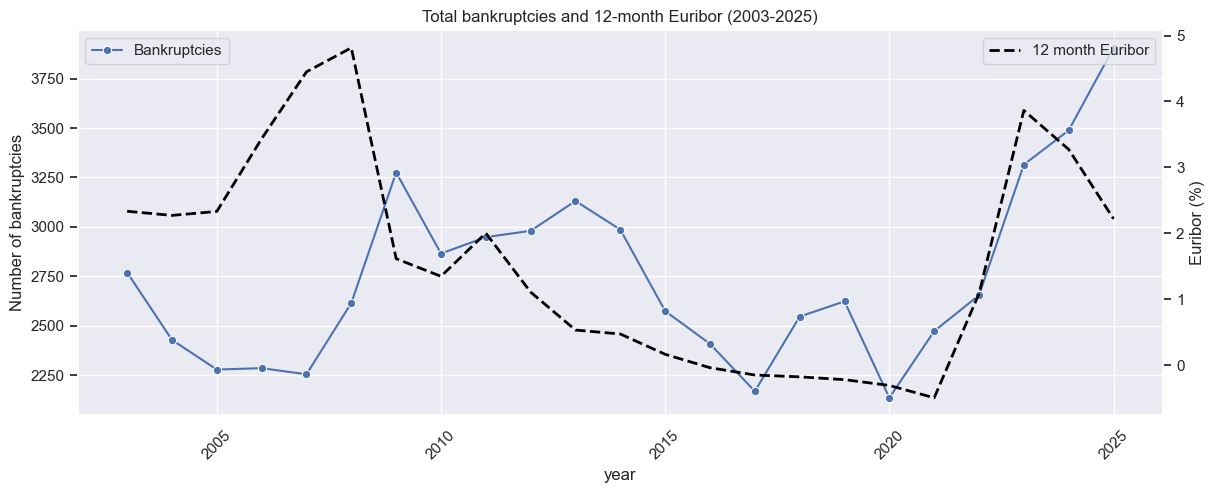

In [9]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme()

fig, ax1 = plt.subplots(figsize=(14, 5))

sns.lineplot(df_by_year, x="year", y="value", marker="o", ax=ax1)
ax1.set_xlabel("year")
ax1.set_ylabel("Number of bankruptcies")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

sns.lineplot(df_euribor_by_year, x="year", y="value", ax=ax2, color="black", linewidth=2, linestyle="--", label="12 month Euribor")

plt.title(f"Total bankruptcies and 12-month Euribor ({year_start}-{year_end})")

ax1.legend(["Bankruptcies"], loc="upper left")
ax2.legend(loc="upper right")
ax2.set_ylabel("Euribor (%)")

# Keeps grid only for bankruptcies
ax1.grid(True)
ax2.grid(False)

plt.show()

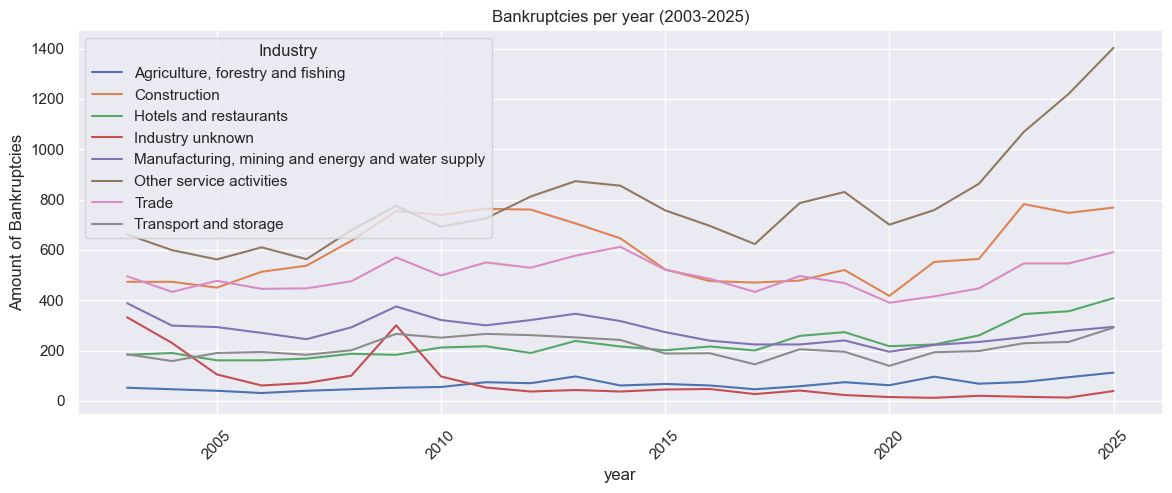

In [10]:
plt.figure(figsize=(14, 5))
sns.lineplot(df_by_industry, x="year", y="value", hue="Industries_luok")
plt.xlabel("year")
plt.ylabel("Amount of Bankruptcies")
plt.title(f"Bankruptcies per year ({year_start}-{year_end})")
plt.xticks(rotation=45)
plt.legend(title="Industry", loc="upper left")

plt.show()

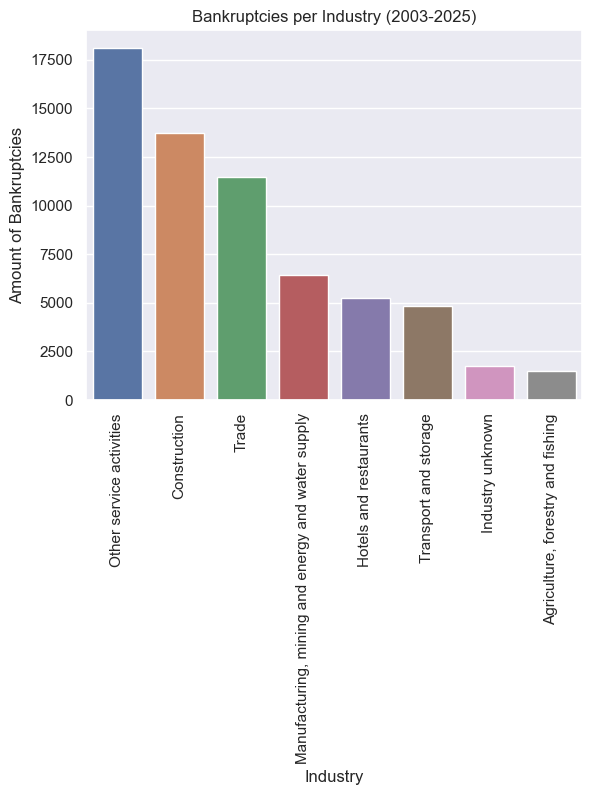

In [11]:
df_industry_total = df_industry_total.sort_values("value", ascending=False)

sns.barplot(df_industry_total, x="Industries_luok", y="value", hue="Industries_luok")
plt.xlabel("Industry")
plt.ylabel("Amount of Bankruptcies")
plt.title(f"Bankruptcies per Industry ({year_start}-{year_end})")
plt.xticks(rotation=90)

plt.show()

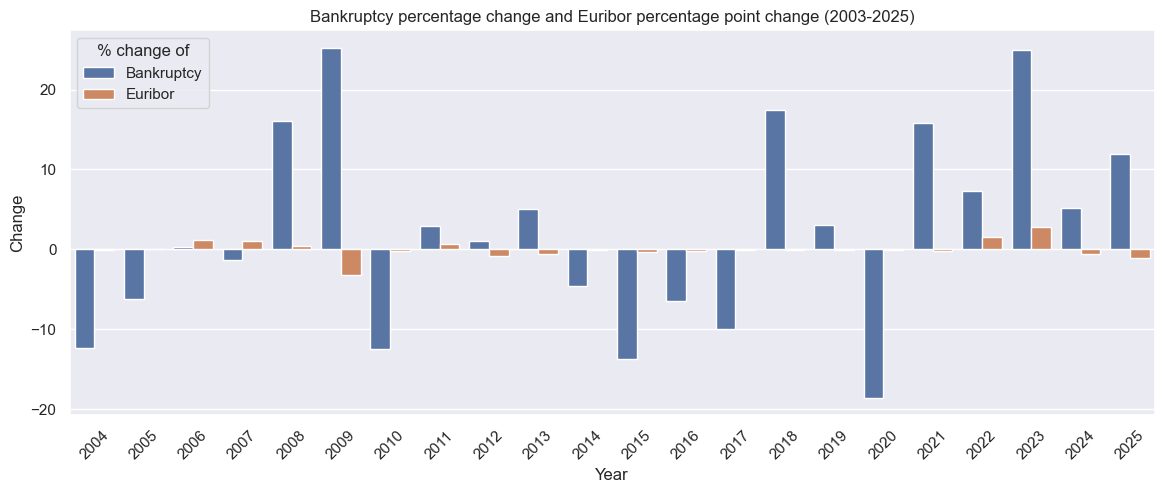

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 5))

sns.barplot(df_long, x="year", y="percentage_change", hue="Series")

plt.title(f"Bankruptcy percentage change and Euribor percentage point change ({year_start}-{year_end})")

plt.xlabel("Year")
plt.ylabel("Change")
plt.xticks(rotation=45)
plt.legend(title="% change of")

plt.show()

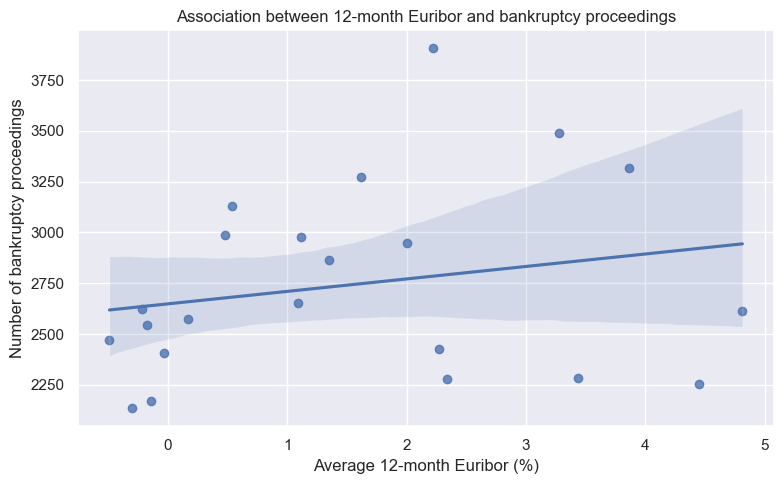

In [13]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_combined,
    x="value_euribor",
    y="value_bankruptcy"
)

plt.xlabel("Average 12-month Euribor (%)")
plt.ylabel("Number of bankruptcy proceedings")
plt.title("Association between 12-month Euribor and bankruptcy proceedings")
plt.tight_layout()
plt.show()

#### 3.2 Pearson correlation

In [14]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df_combined["value_euribor"],
    df_combined["value_bankruptcy"]
)

print("Correlation between Euribor level and bankruptcy level:\n")
print(f"Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Correlation between Euribor level and bankruptcy level:

Correlation: 0.2148
P-value: 0.3371


#### 3.3 Key results

In [15]:
# Bankruptcy dataset

industry_most_bankruptcies = df_industry_total.loc[df_industry_total["value"].idxmax()]
industry_least_bankruptcies = df_industry_total.loc[df_industry_total["value"].idxmin()]
year_most_bankruptcies = df_by_year.loc[df_by_year["value"].idxmax()]
year_least_bankruptcies = df_by_year.loc[df_by_year["value"].idxmin()]
year_largest_increase_bankruptcies = df_combined.loc[df_combined["percentage_change_bankruptcy"].idxmax()]
year_largest_decrease_bankruptcies = df_combined.loc[df_combined["percentage_change_bankruptcy"].idxmin()]

# Euribor dataset
year_highest_euribor = df_euribor_by_year.loc[df_euribor_by_year["value"].idxmax()]
year_lowest_euribor = df_euribor_by_year.loc[df_euribor_by_year["value"].idxmin()]

In [16]:
key_findings = pd.DataFrame([
    {
        "Finding": "Industry with the most bankruptcies",
        "Result": industry_most_bankruptcies["Industries_luok"],
        "Value": round(industry_most_bankruptcies["value"], 2)
     },
     {
       "Finding": "Industry with the least bankruptcies",
        "Result": industry_least_bankruptcies["Industries_luok"],
        "Value": round(industry_least_bankruptcies["value"], 2)  
     },
     {
       "Finding": "Year with the most bankruptcies",
        "Result": year_most_bankruptcies["year"].astype(int),
        "Value": round(year_most_bankruptcies["value"], 2)  
     },
     {
        "Finding": "Year with the least bankruptcies",
        "Result": year_least_bankruptcies["year"].astype(int),
        "Value": round(year_least_bankruptcies["value"], 2) 
     },
     {
        "Finding": "Year with the largest increase in bankruptcies",
        "Result": year_largest_increase_bankruptcies["year"].astype(int),
        "Value": round(year_largest_increase_bankruptcies["percentage_change_bankruptcy"], 2) 
     },
     {
        "Finding": "Year with the largest decrease in bankruptcies",
        "Result": year_largest_decrease_bankruptcies["year"].astype(int),
        "Value": round(year_largest_decrease_bankruptcies["percentage_change_bankruptcy"], 2)
     },
     {
        "Finding": "Year with the highest Euribor",
        "Result": year_highest_euribor["year"].astype(int),
        "Value": round(year_highest_euribor["value"], 2)
     },
     {
        "Finding": "Year with the lowest Euribor",
        "Result": year_lowest_euribor["year"].astype(int),
        "Value": round(year_lowest_euribor["value"], 2)
     },
     {
        "Finding": "Pearson correlation between Euribor and bankruptcies",
        "Result": "Weak positive correlation",
        "Value": round(corr, 4)
     },
     {
        "Finding": "Pearson correlation p-value",
        "Result": "Not statistically significant",
        "Value": round(p_value, 4)
     },
])

key_findings

,Finding,Result,Value
0,Industry with the most bankruptcies,Other service activities,18109.0000
1,Industry with the least bankruptcies,"Agriculture, forestry and fishing",1477.0000
2,Year with the most bankruptcies,2025,3906.0000
3,Year with the least bankruptcies,2020,2135.0000
4,Year with the largest increase in bankruptcies,2009,25.2400
5,Year with the largest decrease in bankruptcies,2020,-18.6000
6,Year with the highest Euribor,2008,4.8100
7,Year with the lowest Euribor,2021,-0.4900
8,Pearson correlation between Euribor and bankru...,Weak positive correlation,0.2148
9,Pearson correlation p-value,Not statistically significant,0.3371


## 4. Exports

In [18]:
os.makedirs("results", exist_ok=True)

df.to_csv("data/cleaned_bankruptcy_data.csv", index=False)
df_euribor.to_csv("data/cleaned_euribor_data.csv", index=False)
df_by_year.to_csv("results/bankruptcies_by_year.csv", index=False)
df_by_industry.to_csv("results/bankruptcies_by_industry.csv", index=False)
df_combined.to_csv("results/bankruptcies_and_euribor.csv", index=False)
key_findings.to_csv("results/key_findings.csv", index=False)

## 5. Conclusion

The analysis of bankruptcy proceedings in Finland from 2003 to 2025 reveals multiple notable patterns across time and industries. `Other service activities` accounted for the most bankruptcies over the period with `18 109` total proceedings, while `Agriculture, forestry and fishing` had the least with `1 477`. The year with the highest number of bankruptcies was 2025 with `3 906` proceedings, while 2020 had the least amount of bankruptcies, most likely because of the government support measures during COVID-19. The largest increase in bankruptcy proceedings occured in 2009 (`+25.2%`), which is consistent with the 2008 financial crisis, while the largest decrease came in 2020 (`-18.6%`).

Regarding the relationship between interest rates and bankruptcies, the Euribor peaked in 2008 at `4.81%` and reached its lowest point in 2021 at `-0.49%`. The Pearson correlation between the annual Euribor level and the number of bankruptcy proceedings was weak and positive (`r = 0.21`, `p = 0.34`). Because the p-value is well above `0.05`, this result is not statistically significant and no reliable linear association between interest rate levels and bankruptcy counts can be concluded from this data alone.

## 6. Statement of AI use

I used ChatGPT for limited support during the project. I used AI with troubleshooting some code issues and to improve the formatting of visualizations. The project topic, data collection, analysis, interpretation and final notebook were completed independently.